--- 贝叶斯推断最终报告 ---
初始设定上限: 10
实际有效簇数 (权重 > 0.05): 8

--- 簇权重分布 ---
Cluster 0: 权重 0.0422  [次要/噪声]
Cluster 1: 权重 0.0657  [核心人群]
Cluster 2: 权重 0.1630  [核心人群]
Cluster 3: 权重 0.0700  [核心人群]
Cluster 4: 权重 0.0309  [次要/噪声]
Cluster 5: 权重 0.0887  [核心人群]
Cluster 6: 权重 0.1037  [核心人群]
Cluster 7: 权重 0.2464  [核心人群]
Cluster 8: 权重 0.1155  [核心人群]
Cluster 9: 权重 0.0740  [核心人群]


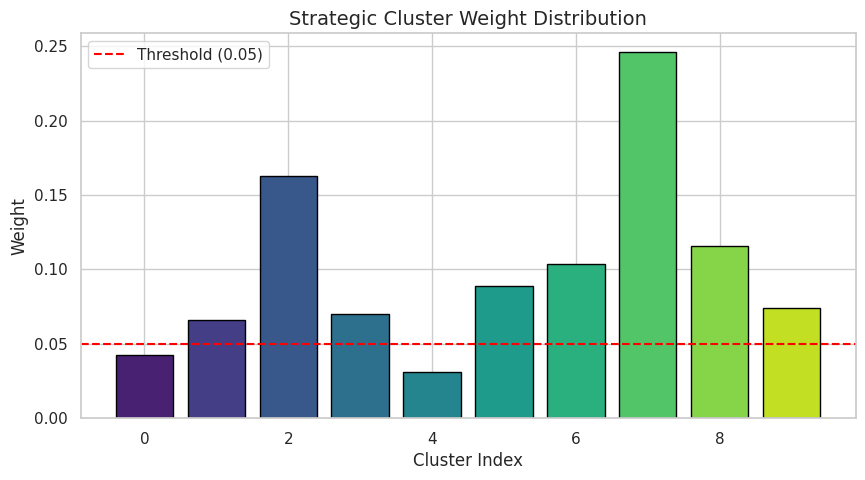

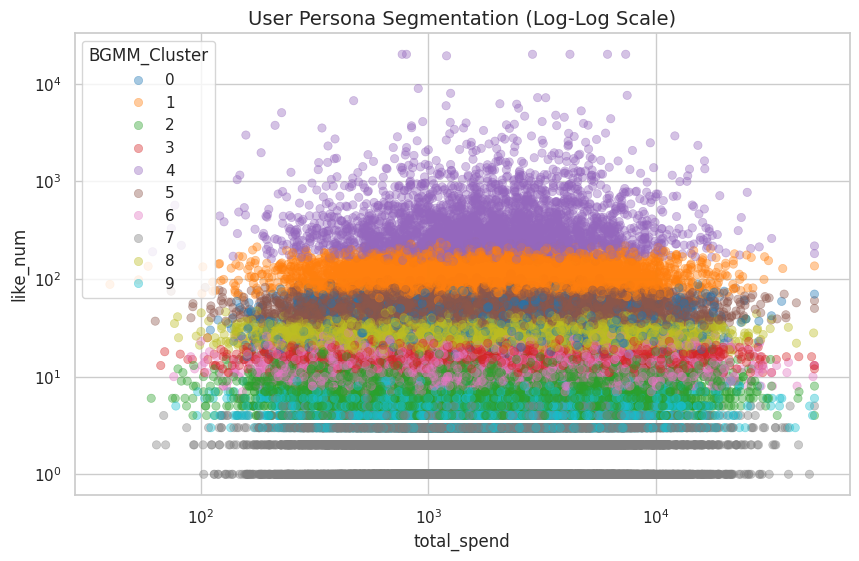

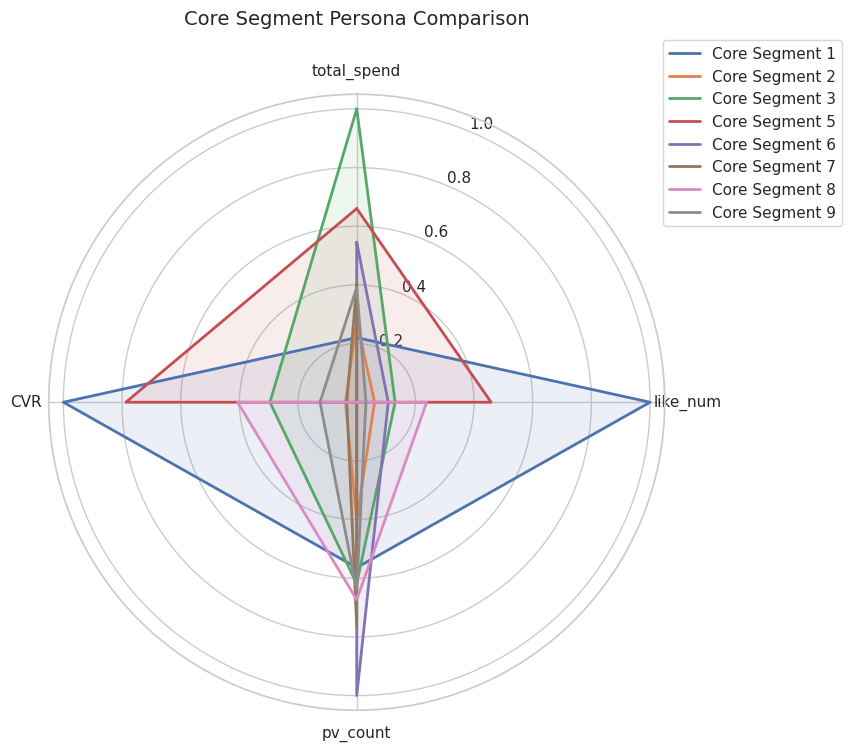

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. 加载数据
df = pd.read_csv('social_ecommerce_data.csv')
features = ['age', 'user_level', 'purchase_freq', 'total_spend', 'like_num', 'comment_num', 'collect_num', 'pv_count']
df_clean = df.dropna(subset=features).reset_index(drop=True)

# 2. 预处理：对数变换 + 标准化
X_log = np.log1p(df_clean[features])
X_scaled = StandardScaler().fit_transform(X_log)

# 3. BGMM 建模 (针对 10w 数据调优)
bgmm = BayesianGaussianMixture(
    n_components=10,
    weight_concentration_prior=0.01,
    covariance_type='diag',
    max_iter=500,
    tol=1e-2,
    random_state=42,
    n_init=1
)
df_clean['BGMM_Cluster'] = bgmm.fit_predict(X_scaled)
weights = bgmm.weights_

# --- 打印推断结果 ---
threshold = 0.05
active_indices = [i for i, w in enumerate(weights) if w > threshold]

print("--- 贝叶斯推断最终报告 ---")
print(f"初始设定上限: 10")
print(f"实际有效簇数 (权重 > {threshold}): {len(active_indices)}")
print("\n--- 簇权重分布 ---")
for i, w in enumerate(weights):
    status = "[核心人群]" if w > threshold else "[次要/噪声]"
    print(f"Cluster {i}: 权重 {w:.4f}  {status}")

# 4. 可视化
sns.set_theme(style="whitegrid")

# 图 1: 权重柱状图
plt.figure(figsize=(10, 5))
plt.bar(range(10), weights, color=sns.color_palette('viridis', 10), edgecolor='black')
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.title('Strategic Cluster Weight Distribution', fontsize=14)
plt.xlabel('Cluster Index')
plt.ylabel('Weight')
plt.legend()
plt.show()

# 图 2: 对数散点图
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='total_spend', y='like_num', hue='BGMM_Cluster', palette='tab10', alpha=0.4, edgecolor=None)
plt.xscale('log'); plt.yscale('log')
plt.title('User Persona Segmentation (Log-Log Scale)', fontsize=14)
plt.show()

# 图 3: 核心簇雷达图 
df_clean['CVR'] = df_clean['label']
# 显式选择数值列进行聚合
radar_cols = ['total_spend', 'like_num', 'pv_count', 'CVR']
active_df = df_clean[df_clean['BGMM_Cluster'].isin(active_indices)]
active_profile = active_df.groupby('BGMM_Cluster')[radar_cols].mean()

scaler = MinMaxScaler()
norm_profile = pd.DataFrame(scaler.fit_transform(active_profile), columns=active_profile.columns, index=active_profile.index)

labels = norm_profile.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, row in norm_profile.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Core Segment {i}')
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('Core Segment Persona Comparison', fontsize=14, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()